# Stacking (blending ensemble)

- an ensemble replacing the _voting rule_ with model trained for prediction

- Use of a linear model, such as linear regression or logistic regression, as the meta-model in a stacking ensemble.   

    - model: $[m_1, m_2, \cdots, m_n]$    
    - prediction: $[\hat{y}_1, \hat{y}_2, \cdots, \hat{y}_n ]$    
$$
\hat{y}_{\text{stack}} = \sum_{i=1}^n \alpha_i \hat{y}_i
$$

- meta-model learns $\alpha_i's$

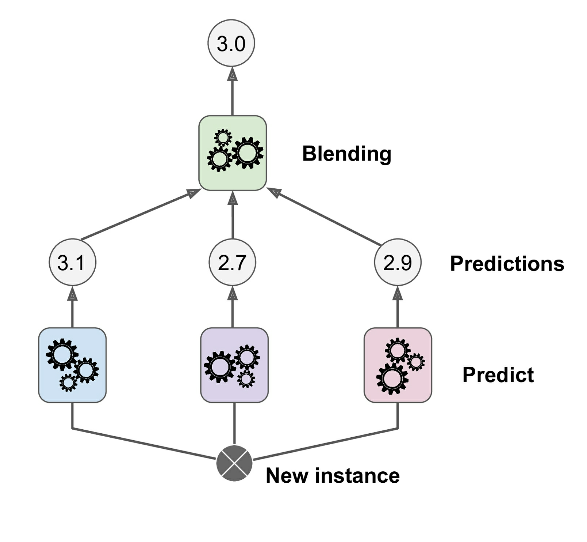

In [ ]:
from IPython.display import Image
Image("G:/python/images/stacking_overview.PNG")   #from Geron

---
### How to approach? Hold-out set

- split training data ino two subsets
- the first training set used to train predictors
- the first predictors are used to predict the training set
   - each model's predictor become the part of input features
- the blender is trained on this new training set (subset + 1st layer predictor) and predict the target values   


>_"We can create a new training set using these predicted values as input features (which makes this new training set 3D),_    
> _and keeping the target values. The blender is trained on this new training set, so it learns to predict the target value,_    
> _given the first layer’s predictions._"


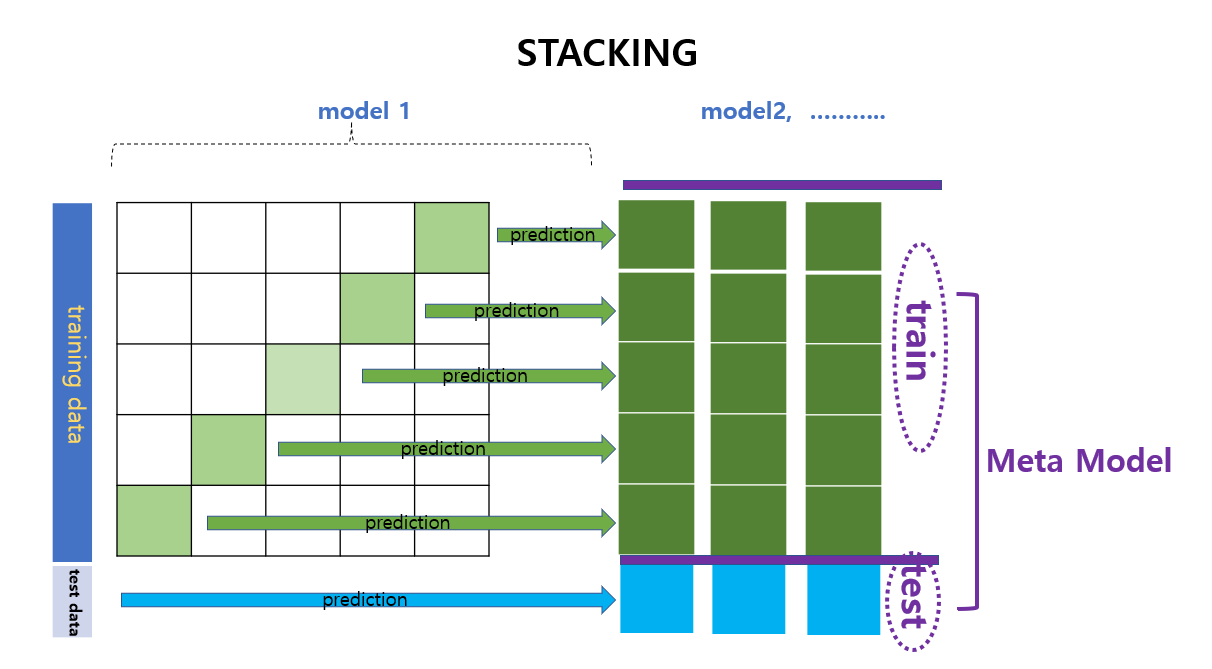

In [ ]:
Image("G:/python/images/stacking.PNG")

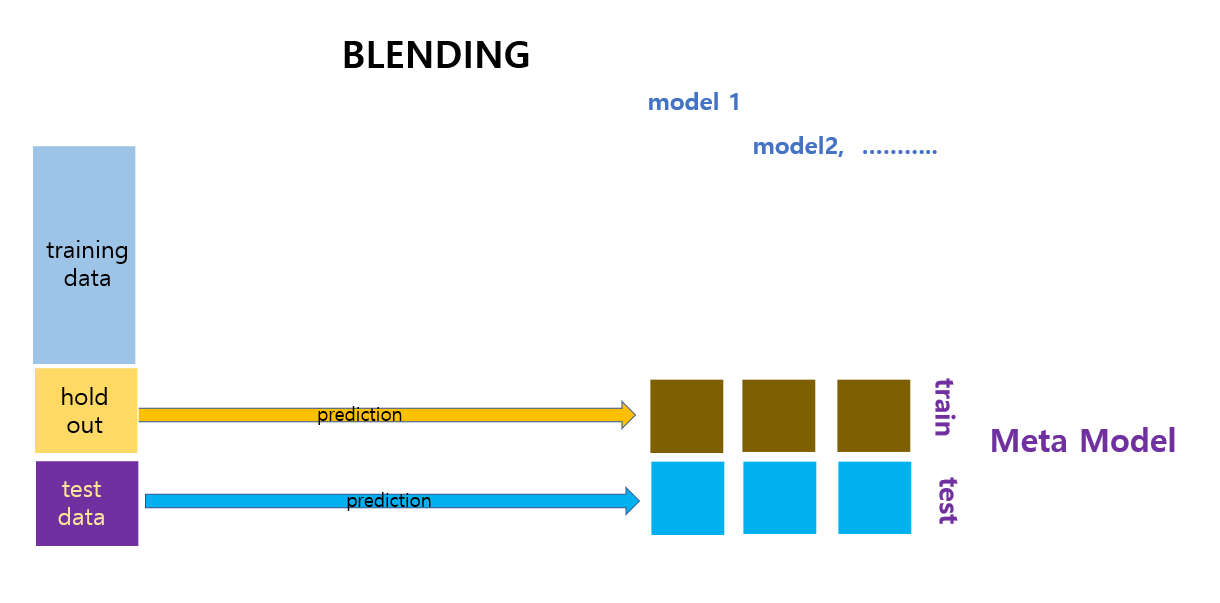

In [ ]:
Image("G:/python/images/blending.PNG")

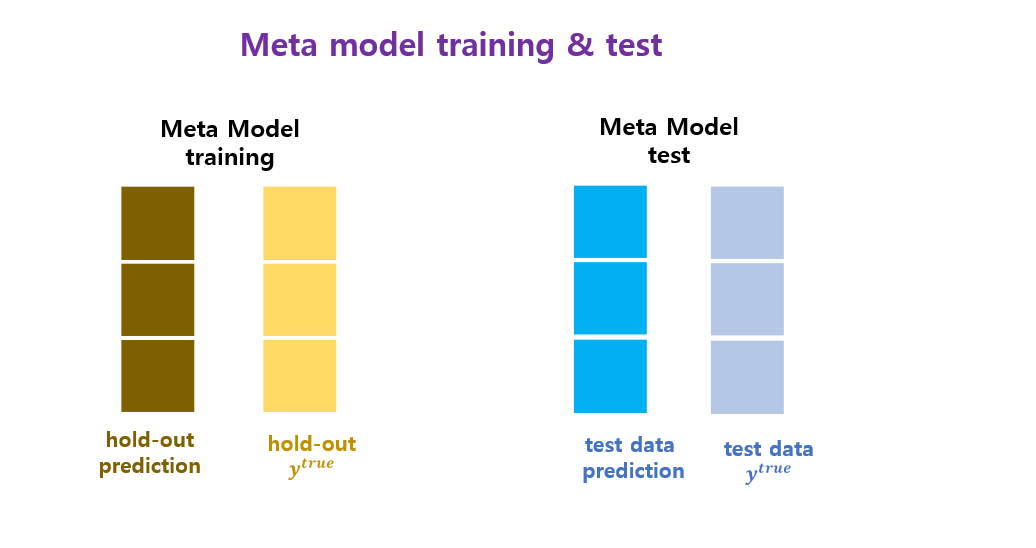

In [ ]:
Image("G:/python/images/meta_model_training_testing.PNG")

## SKlearn stacking library

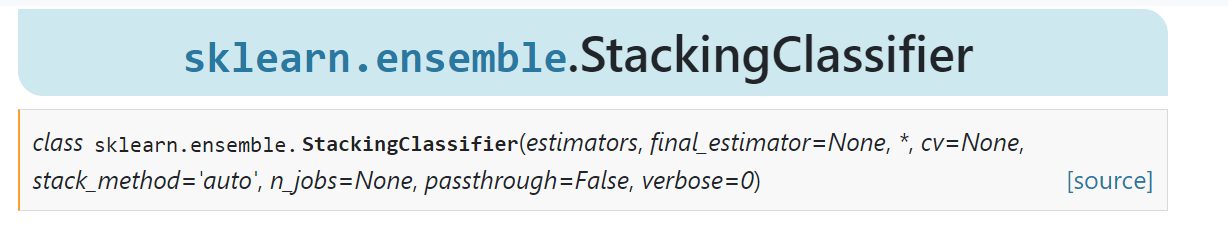

In [ ]:
Image("G:/python/images/sklearn_stacking.PNG")

### Hyper parameters

- `estimators`: base estimators stacked
- `final_estimator`: classifier combining all base estimators
- `stack_method`" {‘auto’, ‘predict_proba’, ‘decision_function’, ‘predict’}


### SKlearn example

```python

>>> from sklearn.datasets import load_iris
>>> from sklearn.ensemble import RandomForestClassifier
>>> from sklearn.svm import LinearSVC
>>> from sklearn.linear_model import LogisticRegression
>>> from sklearn.preprocessing import StandardScaler
>>> from sklearn.pipeline import make_pipeline
>>> from sklearn.ensemble import StackingClassifier
>>> X, y = load_iris(return_X_y=True)
>>> estimators = [
...     ('rf', RandomForestClassifier(n_estimators=10, random_state=42)),
...     ('svr', make_pipeline(StandardScaler(),
...                           LinearSVC(random_state=42)))
... ]
>>> clf = StackingClassifier(
...     estimators=estimators, final_estimator=LogisticRegression()
... )
>>> from sklearn.model_selection import train_test_split
>>> X_train, X_test, y_train, y_test = train_test_split(
...     X, y, stratify=y, random_state=42
... )
>>> clf.fit(X_train, y_train).score(X_test, y_test)
0.9...
```

### Blending empirics

- see [SamSungEle empirics](empirics_samsungele_ta_blender.py)